In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
project_path = "/content/drive/MyDrive/music-success-analytics"

raw_path = project_path + "/raw"
processed_path = project_path + "/processed"
quality_reports_path = project_path + "/quality_reports"

In [ ]:
os.listdir(processed_path)

['spotify_tracks_clean.csv']

In [ ]:
file_path = processed_path + "/spotify_tracks_clean.csv"

df = pd.read_csv(file_path)

df.head()

,track_id,track_name,artist_name,album_name,release_date,release_year,genre,duration_ms,duration_min,popularity,...,key,loudness,mode,instrumentalness,tempo,stream_count,country,explicit,label,label_type
0,TRK-BEBD53DA84E1,Agent every (0),Noah Rhodes,Beautiful instead,2016-04-01,2016,Pop,234194,3.90,55,...,9,-32.22,0,0.436,73.12,13000,Brazil,0,Universal Music,Label
1,TRK-6A32496762D7,Night respond,Jennifer Cole,Table,2022-04-15,2022,Metal,375706,6.26,45,...,0,-14.02,0,0.223,157.74,1000,France,1,Island Records,Label
2,TRK-47AA7523463E,Future choice whatever,Brandon Davis,Page southern,2016-02-23,2016,Rock,289191,4.82,55,...,8,-48.26,1,0.584,71.03,1000,Germany,1,XL Recordings,Label
3,TRK-25ADA22E3B06,Bad fall pick those,Corey Jones,Spring,2015-10-12,2015,Pop,209484,3.49,51,...,1,-34.47,1,0.684,149.00,1000,France,0,Warner Music,Label
4,TRK-9245F2AD996A,Husband,Mark Diaz,Great prove,2022-07-08,2022,Indie,127435,2.12,39,...,10,-17.84,0,0.304,155.85,2000,United States,0,Independent,Independent


In [ ]:
df.shape

(84979, 23)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84979 entries, 0 to 84978
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   track_id          84979 non-null  object 
 1   track_name        84979 non-null  object 
 2   artist_name       84979 non-null  object 
 3   album_name        84979 non-null  object 
 4   release_date      84979 non-null  object 
 5   release_year      84979 non-null  int64  
 6   genre             84979 non-null  object 
 7   duration_ms       84979 non-null  int64  
 8   duration_min      84979 non-null  float64
 9   popularity        84979 non-null  int64  
 10  is_hit            84979 non-null  int64  
 11  danceability      84979 non-null  float64
 12  energy            84979 non-null  float64
 13  key               84979 non-null  int64  
 14  loudness          84979 non-null  float64
 15  mode              84979 non-null  int64  
 16  instrumentalness  84979 non-null  float6

In [ ]:
total_tracks = df["track_id"].nunique()
total_artists = df["artist_name"].nunique()
total_genres = df["genre"].nunique()
total_countries = df["country"].nunique()
total_labels = df["label"].nunique()
avg_popularity = round(df["popularity"].mean(), 2)
total_streams = df["stream_count"].sum()

overview = pd.DataFrame({
    "metric": [
        "Total Tracks",
        "Total Artists",
        "Total Genres",
        "Total Countries",
        "Total Labels",
        "Average Popularity",
        "Total Streams"
    ],
    "value": [
        total_tracks,
        total_artists,
        total_genres,
        total_countries,
        total_labels,
        avg_popularity,
        total_streams
    ]
})

overview

,metric,value
0,Total Tracks,8.497900e+04
1,Total Artists,6.237800e+04
2,Total Genres,1.200000e+01
3,Total Countries,1.000000e+01
4,Total Labels,8.000000e+00
5,Average Popularity,4.816000e+01
6,Total Streams,1.821986e+10


In [ ]:
overview.to_csv(
    quality_reports_path + "/spotify_eda_overview.csv",
    index=False
)

In [ ]:
genre_analysis = (
    df.groupby("genre")
    .agg(
        total_tracks=("track_id", "count"),
        avg_popularity=("popularity", "mean"),
        total_streams=("stream_count", "sum"),
        avg_streams=("stream_count", "mean"),
        hit_rate=("is_hit", "mean")
    )
    .reset_index()
)

genre_analysis["avg_popularity"] = genre_analysis["avg_popularity"].round(2)
genre_analysis["avg_streams"] = genre_analysis["avg_streams"].round(0)
genre_analysis["hit_rate"] = (genre_analysis["hit_rate"] * 100).round(2)

genre_analysis = genre_analysis.sort_values("avg_popularity", ascending=False)

genre_analysis

,genre,total_tracks,avg_popularity,total_streams,avg_streams,hit_rate
0,Classical,7157,48.37,1558460000,217753.0,24.79
9,R&B,7083,48.37,1625618000,229510.0,26.10
8,Pop,7095,48.37,1538150000,216794.0,25.85
4,Hip-Hop,7159,48.36,1906759000,266344.0,25.59
2,EDM,6892,48.21,1533094000,222445.0,24.56
7,Metal,7199,48.19,1604995000,222947.0,25.10
1,Country,7026,48.17,1440408000,205011.0,24.86
5,Indie,7003,48.12,1257850000,179616.0,24.78
3,Folk,7079,48.11,1539040000,217409.0,25.13
11,Rock,7111,47.96,1452040000,204196.0,24.41


Average popularity is very similar across genres, with only small differences between the highest and lowest values. Classical, R&B and Pop show the highest average popularity, while Jazz, Reggaeton and Rock are slightly lower.

Hip-Hop has the highest total stream count among the analyzed genres, suggesting strong overall performance in terms of listening volume. R&B also shows one of the highest average stream counts per track.

The hit rate is relatively balanced across genres, mostly ranging between 24% and 26%. R&B and Pop show slightly higher hit rates compared to the other genres.

In [ ]:
genre_analysis.to_csv(
    quality_reports_path + "/genre_analysis.csv",
    index=False
)

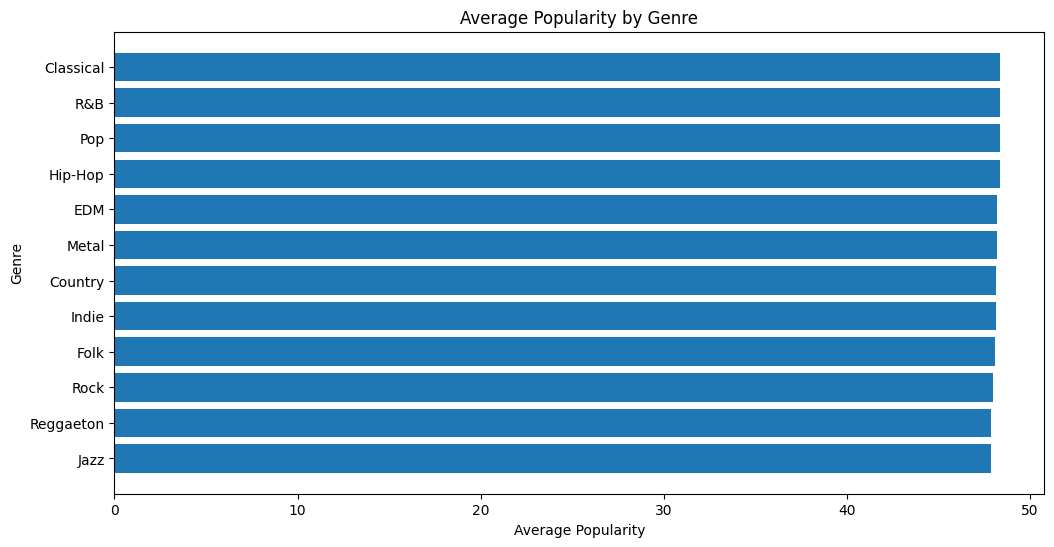

In [ ]:
plt.figure(figsize=(12, 6))

plt.barh(
    genre_analysis["genre"],
    genre_analysis["avg_popularity"]
)

plt.xlabel("Average Popularity")
plt.ylabel("Genre")
plt.title("Average Popularity by Genre")
plt.gca().invert_yaxis()
plt.show()

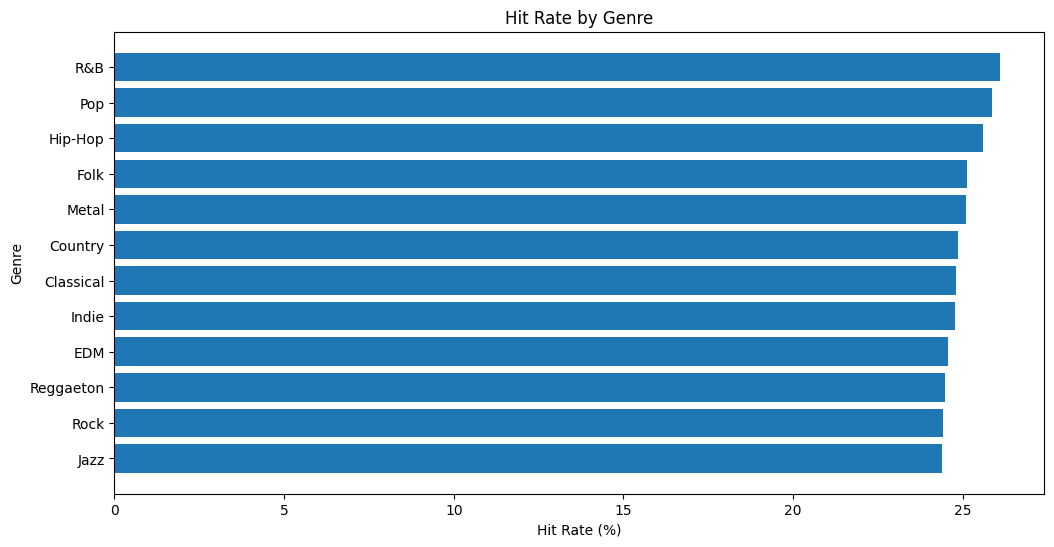

In [ ]:
genre_hit_rate = genre_analysis.sort_values("hit_rate", ascending=False)

plt.figure(figsize=(12, 6))

plt.barh(
    genre_hit_rate["genre"],
    genre_hit_rate["hit_rate"]
)

plt.xlabel("Hit Rate (%)")
plt.ylabel("Genre")
plt.title("Hit Rate by Genre")
plt.gca().invert_yaxis()
plt.show()

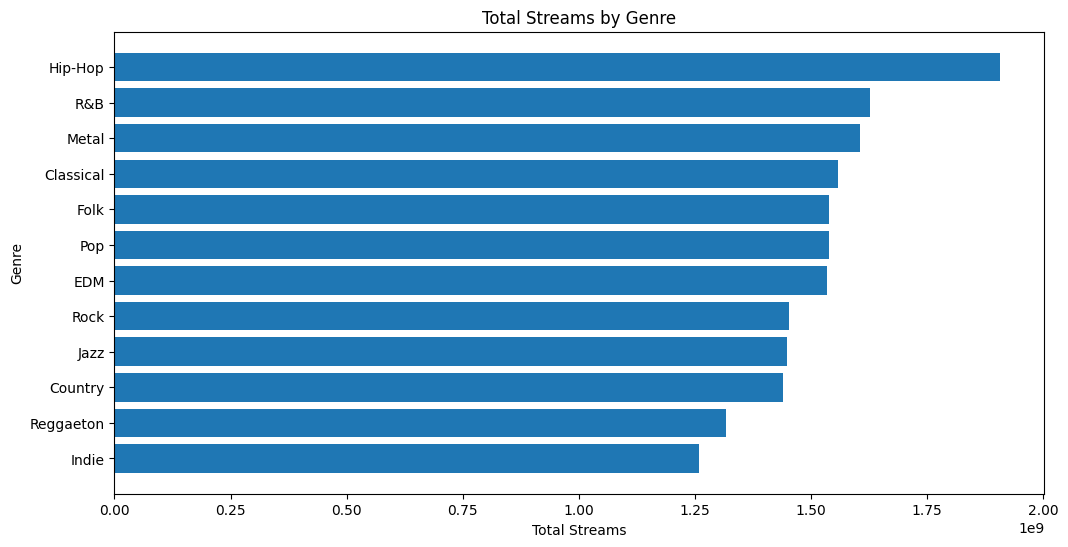

In [ ]:
genre_streams = genre_analysis.sort_values("total_streams", ascending=False)

plt.figure(figsize=(12, 6))

plt.barh(
    genre_streams["genre"],
    genre_streams["total_streams"]
)

plt.xlabel("Total Streams")
plt.ylabel("Genre")
plt.title("Total Streams by Genre")
plt.gca().invert_yaxis()
plt.show()

In [ ]:
hit_analysis = (
    df.groupby("is_hit")
    .agg(
        total_tracks=("track_id", "count"),
        avg_popularity=("popularity", "mean"),
        avg_streams=("stream_count", "mean"),
        avg_danceability=("danceability", "mean"),
        avg_energy=("energy", "mean"),
        avg_loudness=("loudness", "mean"),
        avg_instrumentalness=("instrumentalness", "mean"),
        avg_tempo=("tempo", "mean"),
        avg_duration_min=("duration_min", "mean"),
        explicit_rate=("explicit", "mean")
    )
    .reset_index()
)

hit_analysis["hit_label"] = hit_analysis["is_hit"].map({
    0: "Non-Hit",
    1: "Hit"
})

hit_analysis = hit_analysis[
    [
        "hit_label",
        "total_tracks",
        "avg_popularity",
        "avg_streams",
        "avg_danceability",
        "avg_energy",
        "avg_loudness",
        "avg_instrumentalness",
        "avg_tempo",
        "avg_duration_min",
        "explicit_rate"
    ]
]

hit_analysis = hit_analysis.round(2)

hit_analysis

,hit_label,total_tracks,avg_popularity,avg_streams,avg_danceability,avg_energy,avg_loudness,avg_instrumentalness,avg_tempo,avg_duration_min,explicit_rate
0,Non-Hit,63731,41.55,5485.54,0.52,0.51,-28.03,0.4,130.01,4.25,0.2
1,Hit,21248,67.99,841032.85,0.52,0.50,-27.91,0.4,129.80,4.24,0.2


In [ ]:
hit_analysis.to_csv(
    quality_reports_path + "/hit_vs_non_hit_analysis.csv",
    index=False
)

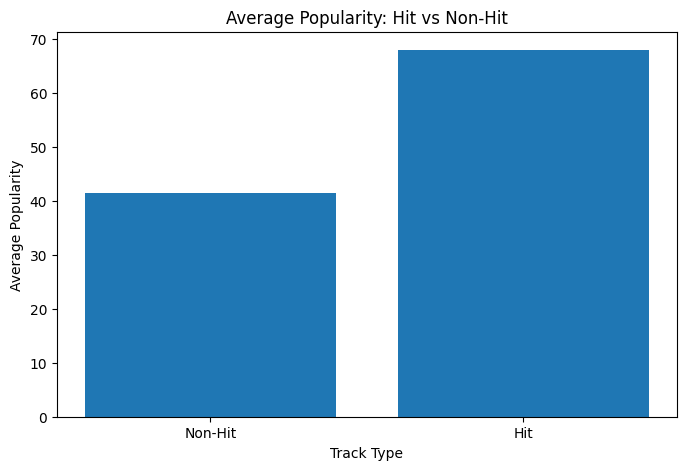

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    hit_analysis["hit_label"],
    hit_analysis["avg_popularity"]
)

plt.xlabel("Track Type")
plt.ylabel("Average Popularity")
plt.title("Average Popularity: Hit vs Non-Hit")
plt.show()

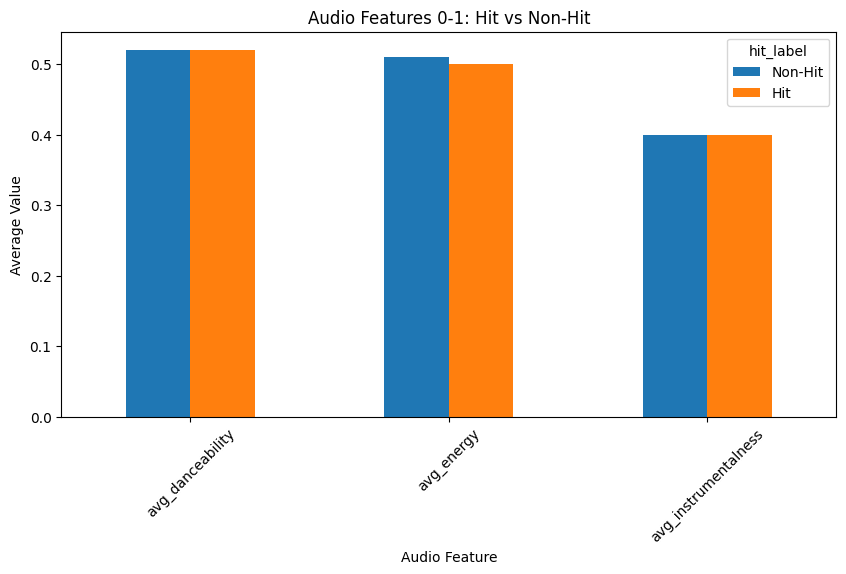

In [ ]:
audio_features_01 = hit_analysis[
    [
        "hit_label",
        "avg_danceability",
        "avg_energy",
        "avg_instrumentalness"
    ]
]

audio_features_01 = audio_features_01.set_index("hit_label")

audio_features_01.T.plot(kind="bar", figsize=(10, 5))

plt.xlabel("Audio Feature")
plt.ylabel("Average Value")
plt.title("Audio Features 0-1: Hit vs Non-Hit")
plt.xticks(rotation=45)
plt.show()

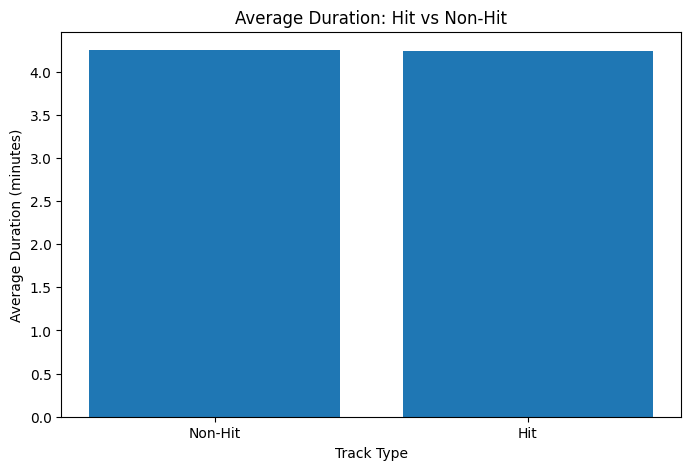

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    hit_analysis["hit_label"],
    hit_analysis["avg_duration_min"]
)

plt.xlabel("Track Type")
plt.ylabel("Average Duration (minutes)")
plt.title("Average Duration: Hit vs Non-Hit")
plt.show()

## Hit vs Non-Hit Analysis

This section compares tracks classified as hits with non-hit tracks.  
A hit is defined as a track belonging to the top 25% of the popularity distribution.  

The comparison includes popularity, streams, audio features, tempo, duration and explicit content rate.  
This analysis helps identify whether successful tracks show different musical or business-related characteristics compared to the rest of the dataset.

Hit tracks show a much higher average stream count compared to non-hit tracks. This suggests a strong relationship between the popularity score and listening volume.

Audio features such as danceability, energy, instrumentalness, tempo and duration show very small differences between hit and non-hit tracks. In this dataset, hit status appears to be more strongly associated with popularity and stream count than with clear differences in basic audio characteristics.

## Hit vs Non-Hit Insights

Hit tracks show a significantly higher average popularity score and a much higher average stream count compared to non-hit tracks. This confirms that the hit classification captures tracks with stronger commercial performance.

However, basic audio features such as danceability, energy, instrumentalness, tempo and duration are very similar between hit and non-hit tracks. In this dataset, hit status seems to be more strongly associated with popularity and stream volume than with clear differences in the selected audio characteristics.

The explicit content rate is also almost identical between the two groups, suggesting that explicit content does not show a strong difference between hit and non-hit tracks in this dataset.

In [ ]:
label_type_analysis = (
    df.groupby("label_type")
    .agg(
        total_tracks=("track_id", "count"),
        avg_popularity=("popularity", "mean"),
        total_streams=("stream_count", "sum"),
        avg_streams=("stream_count", "mean"),
        hit_rate=("is_hit", "mean"),
        avg_danceability=("danceability", "mean"),
        avg_energy=("energy", "mean"),
        avg_tempo=("tempo", "mean")
    )
    .reset_index()
)

label_type_analysis["avg_popularity"] = label_type_analysis["avg_popularity"].round(2)
label_type_analysis["avg_streams"] = label_type_analysis["avg_streams"].round(0)
label_type_analysis["hit_rate"] = (label_type_analysis["hit_rate"] * 100).round(2)
label_type_analysis["avg_danceability"] = label_type_analysis["avg_danceability"].round(2)
label_type_analysis["avg_energy"] = label_type_analysis["avg_energy"].round(2)
label_type_analysis["avg_tempo"] = label_type_analysis["avg_tempo"].round(2)

label_type_analysis

,label_type,total_tracks,avg_popularity,total_streams,avg_streams,hit_rate,avg_danceability,avg_energy,avg_tempo
0,Independent,10763,48.26,2383649000,221467.0,25.22,0.52,0.50,130.02
1,Label,74216,48.15,15836216000,213380.0,24.97,0.52,0.51,129.94


In [ ]:
label_type_analysis.to_csv(
    quality_reports_path + "/label_type_analysis.csv",
    index=False
)

## Label Type Analysis - Insights

Independent and label-backed tracks show very similar performance in this dataset.  
Average popularity is almost identical between the two groups, with Independent tracks showing a slightly higher value.

Independent tracks also show slightly higher average streams and hit rate, although the difference is limited.  
Since label-backed tracks represent a much larger portion of the dataset, total streams are naturally higher for the Label group. For this reason, average streams and hit rate are more useful metrics for comparison.

In [ ]:
label_comparison = label_type_analysis[
    [
        "label_type",
        "avg_popularity",
        "avg_streams",
        "hit_rate"
    ]
].copy()

label_comparison

,label_type,avg_popularity,avg_streams,hit_rate
0,Independent,48.26,221467.0,25.22
1,Label,48.15,213380.0,24.97


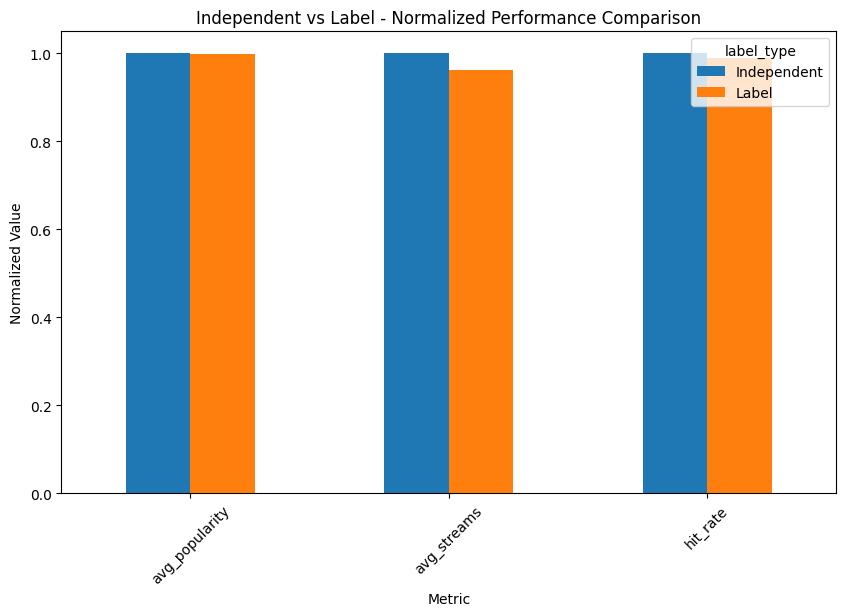

In [ ]:
label_comparison_indexed = label_comparison.set_index("label_type")

label_comparison_normalized = (
    label_comparison_indexed / label_comparison_indexed.max()
)

label_comparison_normalized.T.plot(kind="bar", figsize=(10, 6))

plt.xlabel("Metric")
plt.ylabel("Normalized Value")
plt.title("Independent vs Label - Normalized Performance Comparison")
plt.xticks(rotation=45)
plt.show()

The normalized comparison shows that Independent and label-backed tracks perform very similarly across average popularity, average streams and hit rate. Independent tracks show slightly higher average streams and hit rate, but the difference is limited. For this reason, label type does not appear to create a strong performance gap in this dataset.

In [ ]:
genre_label_type = (
    df.groupby(["genre", "label_type"])
    .agg(
        total_tracks=("track_id", "count"),
        avg_popularity=("popularity", "mean"),
        avg_streams=("stream_count", "mean"),
        hit_rate=("is_hit", "mean")
    )
    .reset_index()
)

genre_label_type["avg_popularity"] = genre_label_type["avg_popularity"].round(2)
genre_label_type["avg_streams"] = genre_label_type["avg_streams"].round(0)
genre_label_type["hit_rate"] = (genre_label_type["hit_rate"] * 100).round(2)

genre_label_type

,genre,label_type,total_tracks,avg_popularity,avg_streams,hit_rate
0,Classical,Independent,927,49.36,317056.0,25.67
1,Classical,Label,6230,48.22,202977.0,24.65
2,Country,Independent,890,47.68,162965.0,24.61
3,Country,Label,6136,48.24,211110.0,24.90
4,EDM,Independent,877,48.66,328412.0,25.43
5,EDM,Label,6015,48.14,206995.0,24.44
6,Folk,Independent,908,47.63,223941.0,24.23
7,Folk,Label,6171,48.18,216448.0,25.26
8,Hip-Hop,Independent,899,48.36,233841.0,26.59
9,Hip-Hop,Label,6260,48.35,271012.0,25.45


In [ ]:
genre_label_type.to_csv(
    quality_reports_path + "/genre_label_type_analysis.csv",
    index=False
)

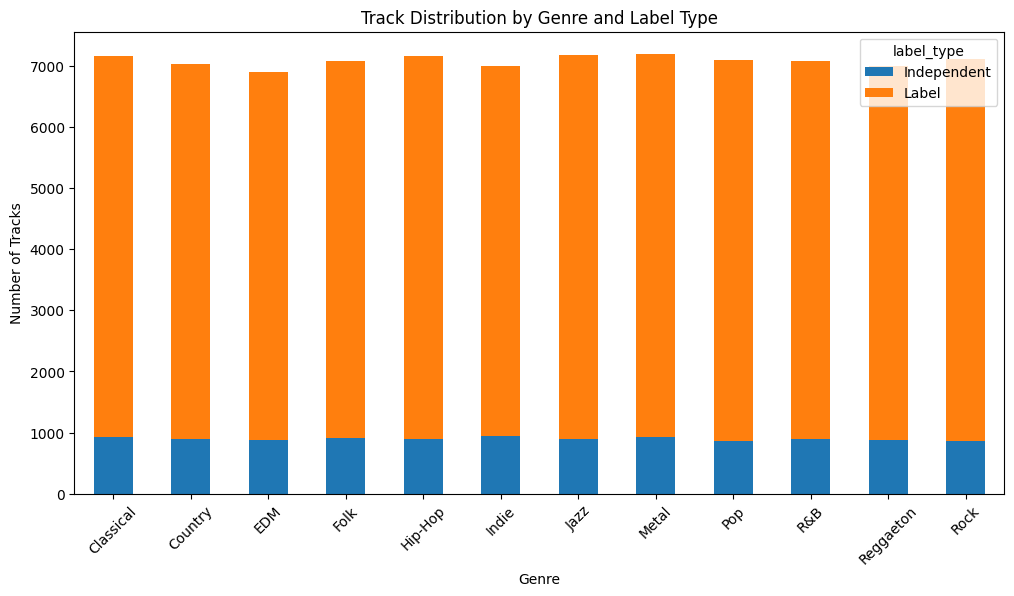

In [ ]:
genre_label_counts = (
    df.groupby(["genre", "label_type"])
    .size()
    .unstack(fill_value=0)
)

genre_label_counts.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.xlabel("Genre")
plt.ylabel("Number of Tracks")
plt.title("Track Distribution by Genre and Label Type")
plt.xticks(rotation=45)
plt.show()

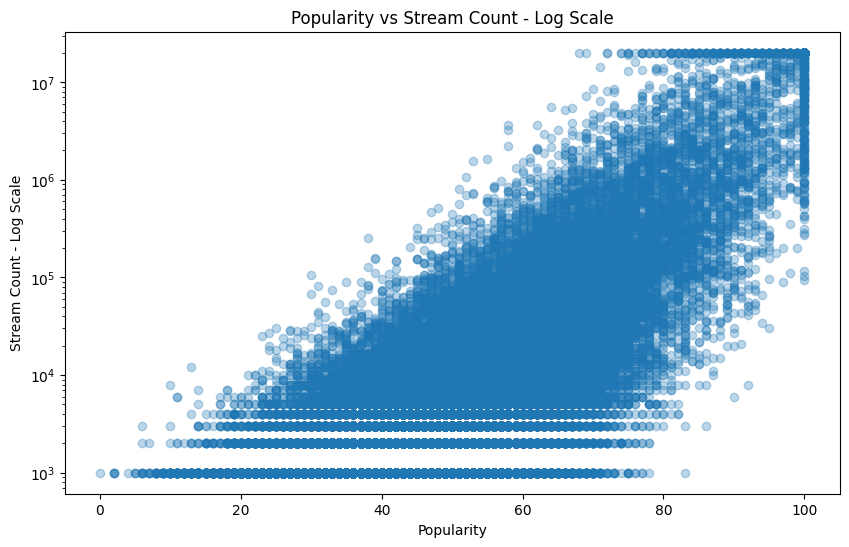

In [ ]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["popularity"],
    df["stream_count"],
    alpha=0.3
)

plt.xlabel("Popularity")
plt.ylabel("Stream Count - Log Scale")
plt.title("Popularity vs Stream Count - Log Scale")
plt.yscale("log")
plt.show()

The log-scale scatter plot shows a positive relationship between popularity and stream count. Tracks with higher popularity generally tend to have higher stream counts, although the spread of points suggests that popularity is influenced by multiple factors and is not explained by stream count alone.

In [ ]:
pop_stream_corr = df["popularity"].corr(df["stream_count"]).round(2)

pop_stream_corr

np.float64(0.36)

The correlation between popularity and stream count is positive but moderate. This indicates that tracks with higher popularity usually have more streams, although other factors may also influence popularity.

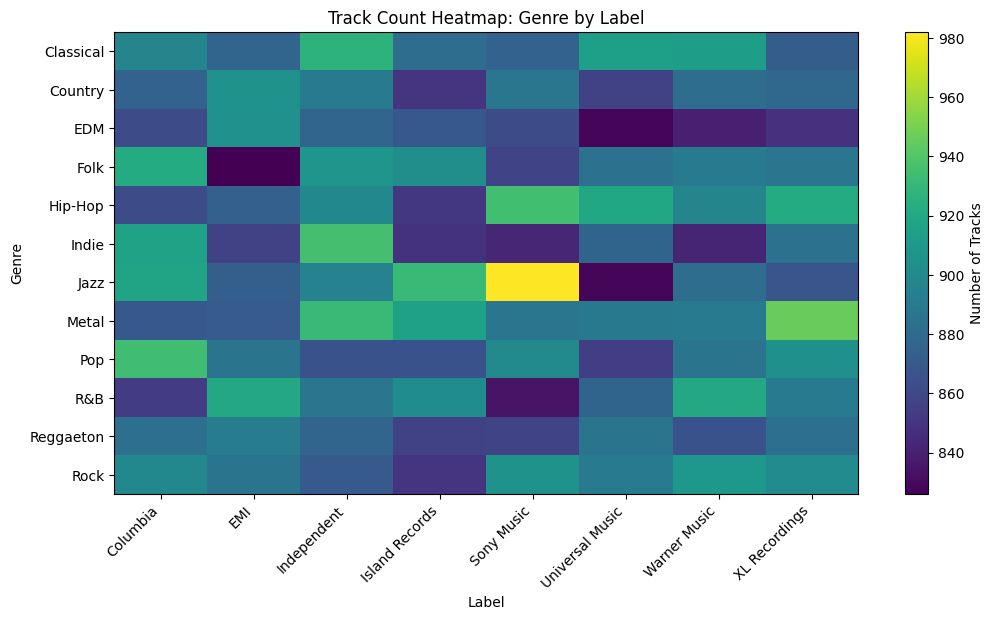

In [ ]:
genre_label_pivot = pd.pivot_table(
    df,
    values="track_id",
    index="genre",
    columns="label",
    aggfunc="count",
    fill_value=0
)

plt.figure(figsize=(12, 6))

plt.imshow(genre_label_pivot, aspect="auto")

plt.xticks(
    ticks=range(len(genre_label_pivot.columns)),
    labels=genre_label_pivot.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    ticks=range(len(genre_label_pivot.index)),
    labels=genre_label_pivot.index
)

plt.xlabel("Label")
plt.ylabel("Genre")
plt.title("Track Count Heatmap: Genre by Label")
plt.colorbar(label="Number of Tracks")

plt.show()

## Genre and Label Distribution Insights

The distribution of genres across labels appears relatively balanced.  
No single label shows a strong dominance in a specific genre, and Independent releases are present across all genres.

This suggests that, within this dataset, genre distribution is fairly uniform across both major labels and independent releases. Because of this balance, label and genre combinations do not show strong concentration patterns.

In [ ]:
country_analysis = (
    df.groupby("country")
    .agg(
        total_tracks=("track_id", "count"),
        avg_popularity=("popularity", "mean"),
        total_streams=("stream_count", "sum"),
        avg_streams=("stream_count", "mean"),
        hit_rate=("is_hit", "mean")
    )
    .reset_index()
)

country_analysis["avg_popularity"] = country_analysis["avg_popularity"].round(2)
country_analysis["avg_streams"] = country_analysis["avg_streams"].round(0)
country_analysis["hit_rate"] = (country_analysis["hit_rate"] * 100).round(2)

country_analysis = country_analysis.sort_values("avg_streams", ascending=False)

country_analysis

,country,total_tracks,avg_popularity,total_streams,avg_streams,hit_rate
6,Japan,8579,48.35,2012939000,234636.0,25.83
3,France,8557,48.33,1968650000,230063.0,25.65
7,Mexico,8337,47.96,1896613000,227493.0,24.10
8,United Kingdom,8454,48.41,1869450000,221132.0,25.40
2,Canada,8618,48.06,1875670000,217646.0,24.45
4,Germany,8548,48.07,1825408000,213548.0,24.77
5,India,8627,48.01,1796792000,208275.0,24.71
1,Brazil,8489,48.31,1754512000,206681.0,25.47
9,United States,8356,48.07,1612336000,192955.0,25.35
0,Australia,8414,48.05,1607495000,191050.0,24.30


In [ ]:
country_analysis.to_csv(
    quality_reports_path + "/country_analysis.csv",
    index=False
)

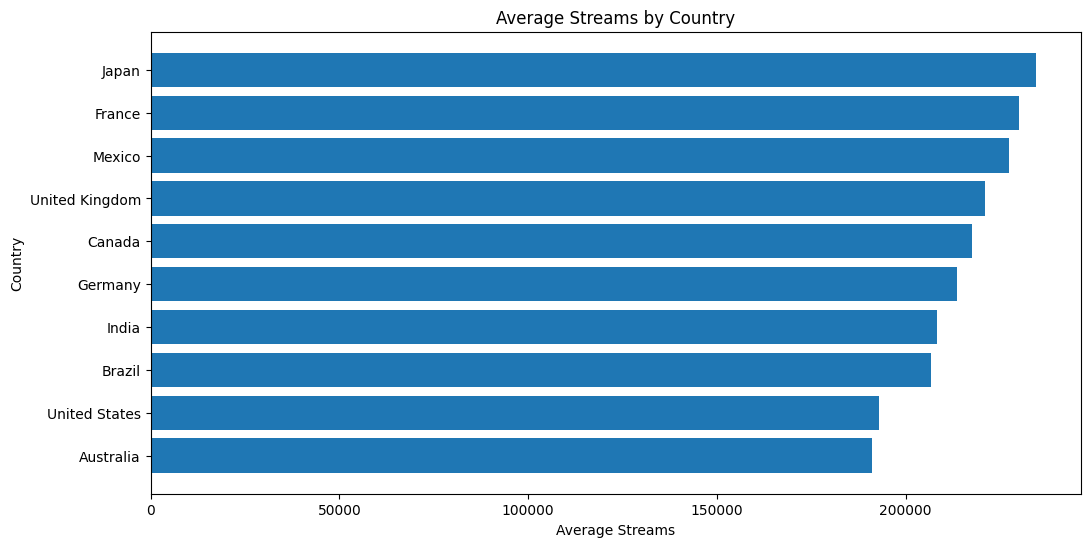

In [ ]:
plt.figure(figsize=(12, 6))

plt.barh(
    country_analysis["country"],
    country_analysis["avg_streams"]
)

plt.xlabel("Average Streams")
plt.ylabel("Country")
plt.title("Average Streams by Country")
plt.gca().invert_yaxis()
plt.show()

In [ ]:
genre_label_type = (
    df.groupby(["genre", "label_type"])
    .agg(
        total_tracks=("track_id", "count"),
        avg_popularity=("popularity", "mean"),
        avg_streams=("stream_count", "mean"),
        hit_rate=("is_hit", "mean")
    )
    .reset_index()
)

genre_label_type["avg_popularity"] = genre_label_type["avg_popularity"].round(2)
genre_label_type["avg_streams"] = genre_label_type["avg_streams"].round(0)
genre_label_type["hit_rate"] = (genre_label_type["hit_rate"] * 100).round(2)

genre_label_type

,genre,label_type,total_tracks,avg_popularity,avg_streams,hit_rate
0,Classical,Independent,927,49.36,317056.0,25.67
1,Classical,Label,6230,48.22,202977.0,24.65
2,Country,Independent,890,47.68,162965.0,24.61
3,Country,Label,6136,48.24,211110.0,24.90
4,EDM,Independent,877,48.66,328412.0,25.43
5,EDM,Label,6015,48.14,206995.0,24.44
6,Folk,Independent,908,47.63,223941.0,24.23
7,Folk,Label,6171,48.18,216448.0,25.26
8,Hip-Hop,Independent,899,48.36,233841.0,26.59
9,Hip-Hop,Label,6260,48.35,271012.0,25.45


In [ ]:
numeric_columns = [
    "popularity",
    "stream_count",
    "danceability",
    "energy",
    "loudness",
    "instrumentalness",
    "tempo",
    "duration_min",
    "explicit",
    "is_hit"
]

correlation_matrix = df[numeric_columns].corr().round(2)

correlation_matrix

,popularity,stream_count,danceability,energy,loudness,instrumentalness,tempo,duration_min,explicit,is_hit
popularity,1.00,0.36,0.00,-0.00,0.00,0.0,-0.00,-0.00,-0.0,0.77
stream_count,0.36,1.00,0.00,-0.00,-0.00,-0.0,-0.00,0.00,-0.0,0.22
danceability,0.00,0.00,1.00,-0.00,0.00,0.0,-0.00,-0.01,0.0,-0.00
energy,-0.00,-0.00,-0.00,1.00,0.01,0.0,-0.01,-0.00,0.0,-0.00
loudness,0.00,-0.00,0.00,0.01,1.00,0.0,-0.00,0.00,0.0,0.00
instrumentalness,0.00,-0.00,0.00,0.00,0.00,1.0,-0.00,-0.00,-0.0,0.00
tempo,-0.00,-0.00,-0.00,-0.01,-0.00,-0.0,1.00,-0.00,-0.0,-0.00
duration_min,-0.00,0.00,-0.01,-0.00,0.00,-0.0,-0.00,1.00,-0.0,-0.00
explicit,-0.00,-0.00,0.00,0.00,0.00,-0.0,-0.00,-0.00,1.0,-0.00
is_hit,0.77,0.22,-0.00,-0.00,0.00,0.0,-0.00,-0.00,-0.0,1.00


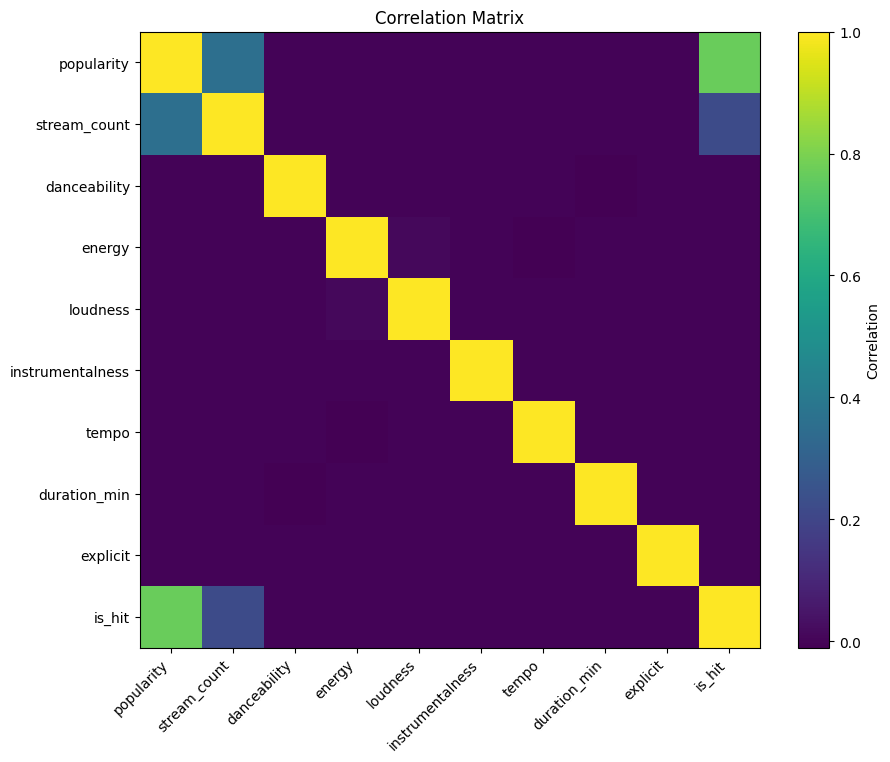

In [ ]:
plt.figure(figsize=(10, 8))

plt.imshow(correlation_matrix, aspect="auto")

plt.xticks(
    ticks=range(len(correlation_matrix.columns)),
    labels=correlation_matrix.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    ticks=range(len(correlation_matrix.index)),
    labels=correlation_matrix.index
)

plt.title("Correlation Matrix")
plt.colorbar(label="Correlation")

plt.show()

## Correlation Analysis - Insights

The strongest correlation is between `popularity` and `is_hit`, which is expected because the hit label was created using the top 25% of the popularity distribution.

`stream_count` shows a moderate positive correlation with `popularity`, suggesting that more popular tracks tend to have higher stream counts. However, the correlation is not perfect, meaning that stream count and popularity are related but not identical metrics.

Basic audio features such as danceability, energy, loudness, instrumentalness, tempo, duration and explicit content show very weak linear correlations with popularity and hit status. This suggests that, in this dataset, commercial performance is not strongly explained by single audio features alone.

In [ ]:
correlation_matrix.to_csv(
    quality_reports_path + "/correlation_matrix.csv"
)

In [ ]:
eda_summary = pd.DataFrame({
    "section": [
        "Overview",
        "Genre Analysis",
        "Hit vs Non-Hit",
        "Label Type Analysis",
        "Country Analysis",
        "Genre x Label Analysis",
        "Correlation Analysis"
    ],
    "main_insight": [
        "The dataset contains cleaned Spotify track-level data with artists, genres, countries, labels, popularity, streams and audio features.",
        "Average popularity is very similar across genres, while Hip-Hop shows strong total stream performance.",
        "Hit tracks have much higher average streams, but basic audio features are very similar between hit and non-hit tracks.",
        "Independent and label-backed tracks perform similarly, with only small differences in average streams and hit rate.",
        "Average streams vary by country, with Japan and France showing the highest average stream values in this dataset.",
        "Genre distribution across labels is relatively balanced, with no strong concentration patterns.",
        "Popularity and stream count show a moderate positive relationship, while most audio features have weak linear correlations with popularity."
    ]
})

eda_summary

,section,main_insight
0,Overview,The dataset contains cleaned Spotify track-lev...
1,Genre Analysis,Average popularity is very similar across genr...
2,Hit vs Non-Hit,"Hit tracks have much higher average streams, b..."
3,Label Type Analysis,Independent and label-backed tracks perform si...
4,Country Analysis,"Average streams vary by country, with Japan an..."
5,Genre x Label Analysis,Genre distribution across labels is relatively...
6,Correlation Analysis,Popularity and stream count show a moderate po...


In [ ]:
eda_summary.to_csv(
    quality_reports_path + "/eda_summary.csv",
    index=False
)

In [ ]:
os.listdir(quality_reports_path)

['data_dictionary.xlsx',
 'spotify_data_quality_report.csv',
 'spotify_cleaning_summary.csv',
 'spotify_eda_overview.csv',
 'genre_analysis.csv',
 'hit_vs_non_hit_analysis.csv',
 'label_type_analysis.csv',
 'country_analysis.csv',
 'genre_label_type_analysis.csv',
 'correlation_matrix.csv',
 'eda_summary.csv']

## Final EDA Summary

This exploratory data analysis investigated Spotify track performance across genres, countries, label types and hit status.

The analysis showed that average popularity is relatively balanced across genres, while Hip-Hop stands out for total stream performance. Hit tracks show much higher average stream counts compared to non-hit tracks, but their basic audio characteristics are very similar.

Independent and label-backed tracks show similar performance, with only small differences in average streams and hit rate. Country-level analysis shows that average streams vary across markets, with Japan and France showing the highest values in this dataset.

The correlation analysis confirms a moderate positive relationship between popularity and stream count, while most audio features show weak linear correlation with popularity. This suggests that future machine learning models may need to combine audio features with business and categorical features such as genre, country and label type.